# **Caso 1 — Análisis exploratorio y de negocio**
## **Hotel Booking Demand · Naowee S.A.S**

**Dataset:** Hotel Booking Demand | **Periodo:** 2015–2017 | **Registros:** ~119 390 | **Variables:** 32

Una cadena hotelera quiere entender el fenómeno de las cancelaciones de reservas,
que afectan la planeación de ocupación e ingresos. Este notebook contiene el análisis
exploratorio completo, soporte estadístico y recomendaciones de negocio.

---
## **Tabla de contenido**
- [01 · Configuración del entorno](#01)
- [02 · Perfilado de datos](#02)
- [03 · Limpieza y transformación](#03)
- [04 · Análisis exploratorio](#04)
- [05 · Análisis estadístico](#05)
- [06 · Tabla resumen de métricas](#06)
- [07 · Riesgos para un modelo futuro](#07)
- [08 · Conclusiones ejecutivas](#08)

## **01. Configuración del entorno**

Para el desarrollo de este análisis se requiere un conjunto de paquetes especializados que facilitan las diferentes etapas del procesamiento y exploración de datos. En primer lugar, se utilizan herramientas para la manipulación y transformación de bases de datos, permitiendo organizar, limpiar y estructurar la información de manera eficiente. Asimismo, se incorporan librerías orientadas al cálculo numérico, fundamentales para realizar operaciones matemáticas y estadísticas sobre grandes volúmenes de datos.

Adicionalmente, se emplean paquetes destinados a la visualización gráfica, los cuales permiten representar patrones, tendencias y distribuciones mediante gráficos claros e interpretables. También se incluyen herramientas para la aplicación de pruebas estadísticas y el análisis inferencial, facilitando la evaluación de relaciones y comportamientos dentro de los datos.

Debido a que la calidad de la información es un aspecto clave en cualquier estudio, se utilizan librerías especializadas en la identificación y visualización de valores faltantes, lo que contribuye a diagnosticar posibles problemas en la base de datos antes de realizar análisis más avanzados. Finalmente, se incorporan utilidades para la gestión del entorno de trabajo, el manejo de archivos y la configuración de parámetros que garantizan la reproducibilidad y consistencia de los resultados obtenidos.


In [ ]:
import kagglehub #Descarga y acceso a conjuntos de datos alojados en Kaggle.
import pandas as pd # Manipulación y análisis de datos tabulares.
import numpy as np # Operaciones numéricas y manejo de arreglos multidimensionales.
import matplotlib.pyplot as plt #Creación de gráficos y visualizaciones personalizadas.
import matplotlib.ticker as mticker #Personalización de escalas y etiquetas en los gráficos.
import seaborn as sns #Visualizaciones estadísticas con un diseño más elaborado.
from scipy import stats #Pruebas estadísticas y análisis inferencial.
import missingno as msno #Exploración visual de datos faltantes.
import warnings #Control de mensajes de advertencia durante la ejecución.
import os #Interacción con directorios y archivos del sistema operativo.

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
SEED = 42
np.random.seed(SEED)

In [27]:
# ── Descarga del dataset desde Kaggle ──────────────────────────────────────
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
print(f"Dataset descargado en: {path}")

# Listar archivos disponibles
for f in os.listdir(path):
    print(" ·", f)

Dataset descargado en: C:\Users\catao\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1
 · hotel_bookings.csv


In [28]:
csv_path = os.path.join(path, "hotel_bookings.csv")
df_raw = pd.read_csv(csv_path)

print(f"Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

Dimensiones: 119,390 filas × 32 columnas


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02


## **02. Perfilado de datos**
Antes de transformar cualquier cosa, entendemos el estado real del dataset:
tipos de dato, valores nulos, duplicados y cardinalidad de cada variable.

El conjunto de datos se estructuran a través de 31 variables que ofrecen una visión detallada de cada reserva hotelera.

**1. Cronología y Estado de la Reserva**
La información temporal es fundamental para el análisis. Se registra el tiempo de antelación (LeadTime) entre el día de la reserva y la llegada, así como los detalles específicos de la fecha de arribo (año, mes, número de semana y día del mes)
. Además, se rastrea cuánto tiempo permaneció una reserva en lista de espera (DaysInWaitingList) antes de confirmarse
. El desenlace de la reserva se captura en variables que indican si fue cancelada (IsCanceled) y cuál fue su estado final (ReservationStatus), ya sea una salida efectiva (check-out), una cancelación o que el cliente no se presentó (no-show).

**2. Composición de los Huéspedes y la Estancia**

Para entender quiénes visitan el hotel, se cuenta el número de adultos, niños y bebés en cada registro. La duración del viaje se desglosa por el número de noches de fin de semana y noches entre semana que el cliente se hospedó o planeó hospedarse.

**3. Preferencias y logística del alojamiento**

Los datos detallan las necesidades específicas de los clientes:

- **Servicios**: El tipo de paquete de comidas reservado (como desayuno incluido o pensión completa) y el número de peticiones especiales (por ejemplo, camas gemelas).

- **Habitaciones**: Se diferencia entre el tipo de habitación reservada y el tipo de habitación asignada, ya que esta última puede variar por razones operativas como el overbooking.

**4. Perfil y Comportamiento del Cliente**

El historial del huésped permite identificar patrones de lealtad y riesgo. Se registra el país de origen y se clasifica al cliente según su tipo (transitorio, bajo contrato o grupal)
. Es posible saber si es un huésped repetido y cuántas reservas previas ha realizado, distinguiendo entre las que fueron canceladas anteriormente y las que no.

**5. Canales de Venta y Variables Financieras**

Finalmente, se describe cómo llega el negocio al hotel a través del segmento de mercado, el canal de distribución y los identificadores anónimos de la agencia de viajes o la empresa responsable
. En términos económicos, se especifica el tipo de depósito realizado para garantizar la estancia y la tarifa diaria promedio (ADR), que calcula el ingreso promedio por noche de alojamiento.



In [29]:
# ── 02 · Perfilado de datos ───────────────────────────────────────────────
df = df_raw.copy()

# Resumen general
print("=" * 55)
print(f"  Filas     : {df.shape[0]:>10,}")
print(f"  Columnas  : {df.shape[1]:>10}")
print(f"  Duplicados: {df.duplicated().sum():>10,}")
print("=" * 55)

df.dtypes.to_frame("tipo").assign(
    nulos=df.isnull().sum(),
    pct_nulos=(df.isnull().mean() * 100).round(2),
    n_unicos=df.nunique(),
).sort_values("pct_nulos", ascending=False)

  Filas     :    119,390
  Columnas  :         32
  Duplicados:     31,994


,tipo,nulos,pct_nulos,n_unicos
company,float64,112593,94.31,352
agent,float64,16340,13.69,333
country,str,488,0.41,177
hotel,str,0,0.00,2
arrival_date_month,str,0,0.00,12
arrival_date_week_number,int64,0,0.00,53
lead_time,int64,0,0.00,479
is_canceled,int64,0,0.00,2
stays_in_weekend_nights,int64,0,0.00,17
stays_in_week_nights,int64,0,0.00,35


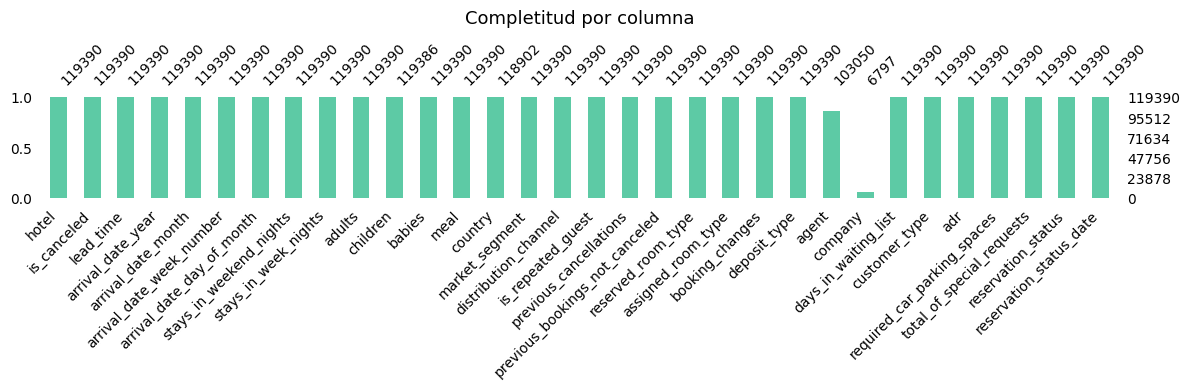

In [30]:
fig, ax = plt.subplots(figsize=(12, 4))
msno.bar(df, ax=ax, color="#5DCAA5", fontsize=10)
ax.set_title("Completitud por columna", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [31]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

card = (
    df[cat_cols]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("n_categorias")
)
card["ejemplo"] = [df[c].dropna().unique()[:3].tolist() for c in card.index]
card

,n_categorias,ejemplo
reservation_status_date,926,"[2015-07-01, 2015-07-02, 2015-07-03]"
country,177,"[PRT, GBR, USA]"
assigned_room_type,12,"[C, A, D]"
arrival_date_month,12,"[July, August, September]"
reserved_room_type,10,"[C, A, D]"
market_segment,8,"[Direct, Corporate, Online TA]"
distribution_channel,5,"[Direct, Corporate, TA/TO]"
meal,5,"[BB, FB, HB]"
customer_type,4,"[Transient, Contract, Transient-Party]"
deposit_type,3,"[No Deposit, Refundable, Non Refund]"


## **03. Limpieza y transformación de datos**

Dos reservas con valores idénticos en las 32 variables —
incluyendo fecha, tarifa, habitación y cliente — son estadísticamente improbables
como eventos reales distintos. Se tratan como artefactos de carga duplicada.

In [32]:
# ── Duplicados ────────────────────────────────────────────────────────────
n_antes = len(df)
df = df.drop_duplicates()
n_despues = len(df)

print(f"Filas eliminadas : {n_antes - n_despues:,}")
print(f"Filas restantes  : {n_despues:,}")

Filas eliminadas : 31,994
Filas restantes  : 87,396


Se realizó una evaluación de los valores faltantes presentes en cada variable. Se identificaron cuatro registros nulos en la variable children (0,00%), 452 en country (0,52%), 12.193 en agent (13,95%) y 82.137 en company (93,98%).
Sin embargo, no todos los valores ausentes representan necesariamente errores o pérdidas de información. De acuerdo con la documentación del conjunto de datos, los valores faltantes en variables como agent y company deben interpretarse en muchos casos como situaciones en las que la reserva no estuvo asociada a una agencia de viajes ni a una empresa, respectivamente. Por esta razón, estos nulos requieren una interpretación diferente a la de un dato faltante convencional.

In [33]:
cols_con_nulos = ["children", "country", "agent", "company"]
for col in cols_con_nulos:
    n = df[col].isnull().sum()
    pct = n / len(df) * 100
    print(f"{col:<12} → {n:>6,} nulos ({pct:.2f}%)")

children     →      4 nulos (0.00%)
country      →    452 nulos (0.52%)
agent        → 12,193 nulos (13.95%)
company      → 82,137 nulos (93.98%)


En el caso de la variable country, los 452 registros sin información representan apenas el 0,52% del total de observaciones. Además, la documentación señala que la ausencia de este dato puede deberse a que la nacionalidad del huésped no siempre es conocida al momento en que se registra la reserva. Dado que los datos fueron extraídos con una marca temporal correspondiente al día anterior a la fecha de llegada, es posible que esta información aún no hubiera sido registrada o validada, especialmente en reservas que posteriormente fueron canceladas.

Debido a que Portugal concentra aproximadamente el 32% de las observaciones y corresponde al país donde se ubican los hoteles, imputar los valores faltantes de country mediante la moda habría incrementado artificialmente la frecuencia de PRT. Para evitar ese sesgo, los 452 registros sin información (0,52%) no se imputaron con la categoría modal y se conservaron como una categoría explícita de ausencia de información (p. ej., Unknown/Missing) o como valores faltantes según el análisis realizado.

In [34]:
print(df["country"].value_counts(normalize=True).head(5))

country
PRT   0.32
GBR   0.12
FRA   0.10
ESP   0.08
DEU   0.06
Name: proportion, dtype: float64


La variable agent presentó 12.193 valores nulos (13,95%). Sin embargo, de acuerdo con la documentación original del conjunto de datos (Antonio et al., 2019), estos registros no corresponden a información faltante, sino a reservas realizadas sin la intermediación de una agencia de viajes. Por esta razón, los valores nulos fueron reemplazados por 0, preservando el significado original de la variable y manteniendo la consistencia con su formato numérico.

Por su parte, la variable company registró 82.137 valores nulos (93,98%). Los valores observados en esta columna corresponden a identificadores numéricos de empresas asociadas a determinadas reservas, mientras que los valores nulos indican que la reserva no fue realizada a través de una empresa. Debido a la elevada proporción de categorías únicas y a que los códigos carecen de una interpretación ordinal o cuantitativa, utilizar directamente estos identificadores en el análisis aportaría poca información.

Con el fin de evaluar la relevancia de esta variable, se compararon las tasas de cancelación entre reservas asociadas a empresas y reservas sin empresa. Los resultados mostraron que las reservas corporativas presentan una tasa de cancelación cercana al 11%, mientras que las reservas sin empresa alcanzan aproximadamente el 29%. Esta diferencia sugiere que la existencia de un vínculo corporativo contiene información relevante para explicar el comportamiento de cancelación.

In [35]:
# ¿Cuántas reservas con empresa son canceladas vs no canceladas?
print(df.groupby(df["company"].notna())["is_canceled"].mean())

company
False   0.29
True    0.11
Name: is_canceled, dtype: float64


En consecuencia, en lugar de conservar los identificadores originales, se transformó la variable company en una variable binaria denominada has_company, donde el valor 1 indica que la reserva está asociada a una empresa y el valor 0 indica que no existe dicha asociación. Esta transformación permite conservar la señal predictiva de la variable, reducir la dimensionalidad y mejorar su interpretabilidad dentro de los modelos posteriores.

In [36]:
# ── Tratamiento de nulos ──────────────────────────────────────────────────

# children: 4 nulos → 0
# Registros con adultos presentes y sin bebés; ausencia equivale a sin niños
df["children"] = df["children"].fillna(0).astype(int)

# country: 452 nulos → "Unknown"
# Imputar con moda (PRT, 32%) introduciría sesgo geográfico artificial
df["country"] = df["country"].fillna("Unknown")

# agent: 12,193 nulos → 0.0
# Según el paper original (Antonio et al., 2019), NULL en agent significa
# "reserva sin agente de viajes", no un dato faltante. Se codifica como 0.0
# coherente con el tipo float64 de la columna
df["agent"] = df["agent"].fillna(0.0)

# company: 82,137 nulos (~94%) → flag binario
# NULL significa "reserva no corporativa" (Antonio et al., 2019)
# Las reservas corporativas tienen tasa de cancelación de 11% vs 29% sin empresa
# → la señal está en la presencia, no en el ID
df["has_company"] = df["company"].notna().astype(int)
df = df.drop(columns=["company"])

# Verificación
print("Nulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nhas_company: {df['has_company'].value_counts().to_dict()}")

Nulos restantes:
Series([], dtype: int64)

has_company: {0: 82137, 1: 5259}


### Registros anómalos

Antes de eliminar cualquier registro, exploramos el contexto de cada anomalía.
La regla general es: no eliminar por el valor en sí, sino por lo que ese valor
significa operativamente.

In [37]:
# ── Exploración de anómalos ───────────────────────────────────────────────

# 1. Reservas sin ningún huésped
mask_sin_huesped = (df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)
print(f"Reservas sin huésped: {mask_sin_huesped.sum()}")

# 2. ADR igual a cero
mask_adr_cero = df["adr"] == 0
print(f"Reservas con ADR = 0: {mask_adr_cero.sum()}")

# 3. ADR negativo
mask_adr_neg = df["adr"] < 0
print(f"Reservas con ADR negativo: {mask_adr_neg.sum()}")

Reservas sin huésped: 166
Reservas con ADR = 0: 1778
Reservas con ADR negativo: 1


Existe un único **registro con tarifa de negativa de** **-6.38** y estado `Check-Out` en Resort Hotel. Una tarifa negativa en una estadía confirmada, podría tratarse de un reembolso o ajuste contable, sin embargo, no se cuenta con información suficiente para afirmar esto y dado que existo un unico registro podría tratarse de un error de registro.

In [38]:
df[mask_adr_neg][["hotel", "adr", "is_canceled", "reservation_status", "customer_type"]]

,hotel,adr,is_canceled,reservation_status,customer_type
14969,Resort Hotel,-6.38,0,Check-Out,Transient-Party


De los 166 registros de **reservas sin huesped**: 150 tienen estado `Check-Out` con valores positivos de ADR, es decir, se registra una estadía real con tarifa cobrada, pero sin ningún huésped en el
formulario. Puesto que no es posible hacer check out sin contar con almenos un adulto, esto puede tratarse de errores en el sistema de reservas.

**15 canceladas y 1 No-Show** con ADR = 0: indican reservas sin huésped ni tarifa. No representan ningún evento real.

En ambos casos la decisión es eliminar. Conservarlos distorsionaría cualquier análisis de ocupación, segmentación de clientes o comportamiento de cancelación.

In [22]:
df[mask_sin_huesped][["hotel", "is_canceled", "adr", "reservation_status"]].value_counts()

hotel         is_canceled  adr     reservation_status
City Hotel    0            0.00    Check-Out             110
              1            0.00    Canceled               13
Resort Hotel  0            0.00    Check-Out               9
              1            0.00    Canceled                2
City Hotel    0            50.87   Check-Out               2
Resort Hotel  0            28.00   Check-Out               1
City Hotel    1            0.00    No-Show                 1
              0            56.27   Check-Out               1
                           57.30   Check-Out               1
                           6.00    Check-Out               1
                           3.38    Check-Out               1
                           136.46  Check-Out               1
                           77.53   Check-Out               1
                           1.00    Check-Out               1
                           69.50   Check-Out               1
                           32.8

Ante **ADR = 0: 1,778 registros** se encuentra que 1,554 Check-Out corresponden en su mayoría a clientes `Transient` y `Transient-Party`. Pueden ser huespedes que reservan de forma independiente a agencias/compañias o huespedes que reservan por separado pero solicitan registros vinculados en el sistema. Puesto que los datos son anonimos, no es posible distinguirlos con certeza, pero eliminarlos masivamente distorsionaría la distribución real de ocupación.

Tambien se identifican 183 cancelaciones y No-Shows, lo cual puede indicar casos en los que la reserva no requirió un deposito anticipado y finalizaron en una cancelación, ya sea por cancelación o porque el cliente no se presentó, no generó cargos por alojamiento según los registros del sistema.

Finalmente, se conservan los casos con ADR = 0 puesto que representan casos reales.

In [23]:
df[mask_adr_cero][["hotel", "is_canceled", "reservation_status", "customer_type"]].value_counts().head(15)

hotel         is_canceled  reservation_status  customer_type  
City Hotel    0            Check-Out           Transient          744
Resort Hotel  0            Check-Out           Transient          469
City Hotel    0            Check-Out           Transient-Party    204
Resort Hotel  0            Check-Out           Transient-Party    137
City Hotel    1            Canceled            Transient           72
Resort Hotel  1            Canceled            Transient           40
City Hotel    1            Canceled            Transient-Party     22
Resort Hotel  1            Canceled            Group               17
City Hotel    1            No-Show             Transient           15
Resort Hotel  0            Check-Out           Contract            12
City Hotel    0            Check-Out           Contract            11
Resort Hotel  1            No-Show             Transient            9
                           Canceled            Transient-Party      8
              0            

In [39]:
# ── Registros anómalos ────────────────────────────────────────────────────

# 1. ADR negativo → error de registro (1 caso)
df = df[df["adr"] >= 0]

# 2. Reservas sin ningún huésped → error de captura (166 casos)
mask_sin_huesped = (df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)
df = df[~mask_sin_huesped]

# ADR = 0 se conserva → estadías gratuitas, cortesías y cancelaciones
# con tarifa cero son operativamente válidas

print(f"Filas tras limpieza de anómalos: {df.shape[0]:,}")
print(f"  - Eliminados: {df_raw.shape[0] - df.shape[0]:,}")

Filas tras limpieza de anómalos: 87,229
  - Eliminados: 32,161


### Construcción de fechas 
Las fechas de llegada llegan fragmentadas en tres columnas separadas y el mes
en formato texto inglés. Se consolidan en una sola variable `arrival_date` para
habilitar análisis temporales directos. Adicionalmente se construyen variables
derivadas de negocio que se usarán a lo largo del análisis.

In [41]:
print(df[["arrival_date_year", "arrival_date_month", "arrival_date_day_of_month", 
          "stays_in_weekend_nights", "stays_in_week_nights",
          "reservation_status_date"]].head(5))

print(f"\nTipo reservation_status_date: {df['reservation_status_date'].dtype}")
print(f"Tipo arrival_date_year: {df['arrival_date_year'].dtype}")

   arrival_date_year arrival_date_month  arrival_date_day_of_month  \
0               2015               July                          1   
1               2015               July                          1   
2               2015               July                          1   
3               2015               July                          1   
4               2015               July                          1   

   stays_in_weekend_nights  stays_in_week_nights reservation_status_date  
0                        0                     0              2015-07-01  
1                        0                     0              2015-07-01  
2                        0                     1              2015-07-02  
3                        0                     1              2015-07-02  
4                        0                     2              2015-07-03  

Tipo reservation_status_date: str
Tipo arrival_date_year: int64


In [42]:
# ── Fechas ────────────────────────────────────────────────────────────────

# arrival_date_month viene en inglés → mapear a número
month_map = {
    "January": 1, "February": 2, "March": 3,  "April": 4,
    "May": 5,     "June": 6,     "July": 7,    "August": 8,
    "September":9,"October": 10, "November":11,"December": 12
}
df["arrival_date_month_num"] = df["arrival_date_month"].map(month_map)

# Construir fecha completa de llegada
df["arrival_date"] = pd.to_datetime(dict(
    year  = df["arrival_date_year"],
    month = df["arrival_date_month_num"],
    day   = df["arrival_date_day_of_month"]
))

# reservation_status_date viene como string → datetime
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

print(f"Rango de fechas de llegada:")
print(f"  Desde : {df['arrival_date'].min().date()}")
print(f"  Hasta : {df['arrival_date'].max().date()}")

Rango de fechas de llegada:
  Desde : 2015-07-01
  Hasta : 2017-08-31


In [43]:
# ── Variables derivadas ───────────────────────────────────────────────────

# Total de noches por estancia
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Ingreso estimado por reserva (solo reservas no canceladas con ADR > 0)
df["ingreso_estimado"] = df["adr"] * df["total_nights"]
df.loc[(df["is_canceled"] == 1) | (df["adr"] == 0), "ingreso_estimado"] = 0

# Periodo año-mes para agregaciones de negocio
df["periodo"] = df["arrival_date"].dt.to_period("M")

print(df[["arrival_date", "total_nights", "ingreso_estimado", "periodo"]].head(5))

  arrival_date  total_nights  ingreso_estimado  periodo
0   2015-07-01             0              0.00  2015-07
1   2015-07-01             0              0.00  2015-07
2   2015-07-01             1             75.00  2015-07
3   2015-07-01             1             75.00  2015-07
4   2015-07-01             2            196.00  2015-07


### Variables construidas

| Variable | Fórmula | Justificación |
|---|---|---|
| `arrival_date` | `year` + `month` + `day` | Consolida las tres columnas de fecha en una sola variable temporal operable |
| `total_nights` | `stays_in_weekend_nights` + `stays_in_week_nights` | Duración real de la estadía; evita recalcular en cada análisis |
| `ingreso_estimado` | `adr × total_nights` | Ingreso aproximado por reserva; se asigna 0 a canceladas y ADR=0 porque no generaron ingreso real |
| `periodo` | `arrival_date` truncado a mes | Permite agregaciones temporales mes a mes para el análisis de estacionalidad y la tabla resumen |


In [44]:
print(f"Shape final: {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
print(f"Tipos nuevos:\n{df[['arrival_date','reservation_status_date','total_nights','ingreso_estimado','periodo']].dtypes}")

Shape final: (87229, 37)
Nulos restantes: 0
Tipos nuevos:
arrival_date               datetime64[us]
reservation_status_date    datetime64[us]
total_nights                        int64
ingreso_estimado                  float64
periodo                         period[M]
dtype: object


# **04. Análisis exploratorio**
## **Estacionalidad de la demanda**

### Hallazgos — Estacionalidad de la demanda

**Volumen de reservas**

La demanda muestra un patrón estacional consistente con valles en diciembre–enero y picos en verano (julio–agosto) y otoño (octubre). Más relevante aún es muestra una tendencia con pendiente positiva, es decir el volumen de reservas crece sostenidamente a lo largo del periodo, pasando de ~1,700 reservas mensuales en julio 2015 a ~4,500 en mayo 2017.

**Tasa de cancelación**

La tasa de cancelación es alta, oscila entre 15% y 37%, adicionalmente muestra una tendencia creciente a lo largo del periodo. En julio 2015 era del
27.5%; en agosto 2017 llega al 36.8%. Esto indica que el hotel recibe cada vez más reservas, pero proporcionalmente las también cancelaciones aumentan. Los meses de mayor demanda coinciden con tasas de cancelación elevadas. Agosto 2017 es el mes de mayor volumen del periodo entero con una cancelación de casi 4 de cada 10 reservas. 

> **Implicación de negocio:** el crecimiento en reservas no se traduce  proporcionalmente en crecimiento de ocupación real. La cadena necesita políticas diferenciadas por temporada — ya sea overbooking controlado, depósitos obligatorios o incentivos para confirmar reservas anticipadas en los meses de alta demanda.

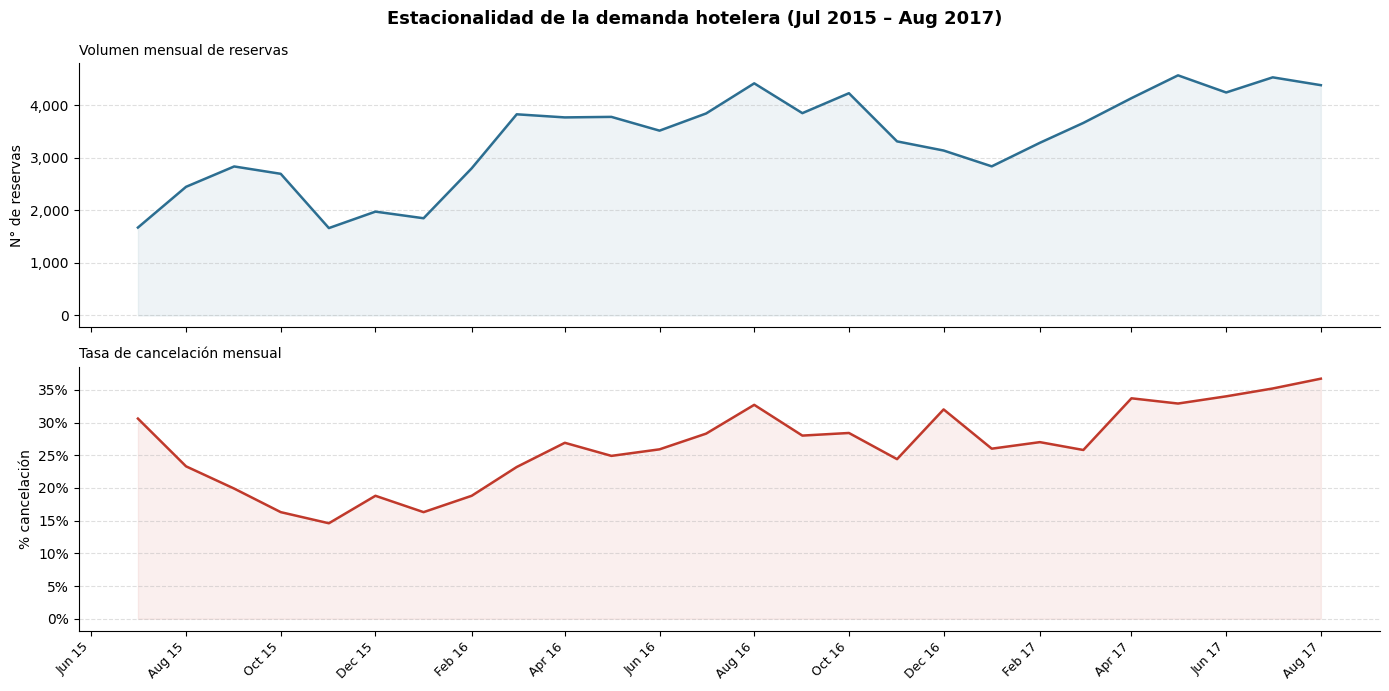

In [48]:
# ── 4.1 Estacionalidad de la demanda ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Estacionalidad de la demanda hotelera (Jul 2015 – Aug 2017)",
             fontsize=13, fontweight="bold")

# ── Panel superior: volumen ──
axes[0].plot(estacionalidad_ts["periodo_dt"], estacionalidad_ts["n_reservas"],
             color="#2C6E91", linewidth=1.8)
axes[0].fill_between(estacionalidad_ts["periodo_dt"], estacionalidad_ts["n_reservas"],
                     alpha=0.08, color="#2C6E91")
axes[0].set_ylabel("N° de reservas", fontsize=10)
axes[0].set_title("Volumen mensual de reservas", fontsize=10, loc="left")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].spines[["top","right"]].set_visible(False)

# ── Panel inferior: tasa de cancelación ──
axes[1].plot(estacionalidad_ts["periodo_dt"], estacionalidad_ts["pct_cancelacion"],
             color="#C0392B", linewidth=1.8)
axes[1].fill_between(estacionalidad_ts["periodo_dt"], estacionalidad_ts["pct_cancelacion"],
                     alpha=0.08, color="#C0392B")
axes[1].set_ylabel("% cancelación", fontsize=10)
axes[1].set_title("Tasa de cancelación mensual", fontsize=10, loc="left")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
axes[1].spines[["top","right"]].set_visible(False)

# ── Eje X compartido ──
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %y"))
axes[1].xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

## **Lead time vs cancelación**
El gráfico de distribución muestra dos poblaciones claramente separadas: las
reservas no canceladas se concentran fuertemente en los primeros días de
anticipación (mediana 38 días), mientras que las canceladas tienen una
distribución más dispersa y desplazada hacia la derecha (mediana 80 días).

In [49]:
print(df.groupby("is_canceled")["lead_time"].describe().round(1))
print(f"\nCorrelación lead_time / is_canceled: {df['lead_time'].corr(df['is_canceled']):.3f}")

               count   mean   std  min   25%   50%    75%    max
is_canceled                                                     
0           63220.00  70.20 81.70 0.00  7.00 38.00 110.00 737.00
1           24009.00 105.70 91.80 0.00 32.00 80.00 158.00 629.00

Correlación lead_time / is_canceled: 0.185


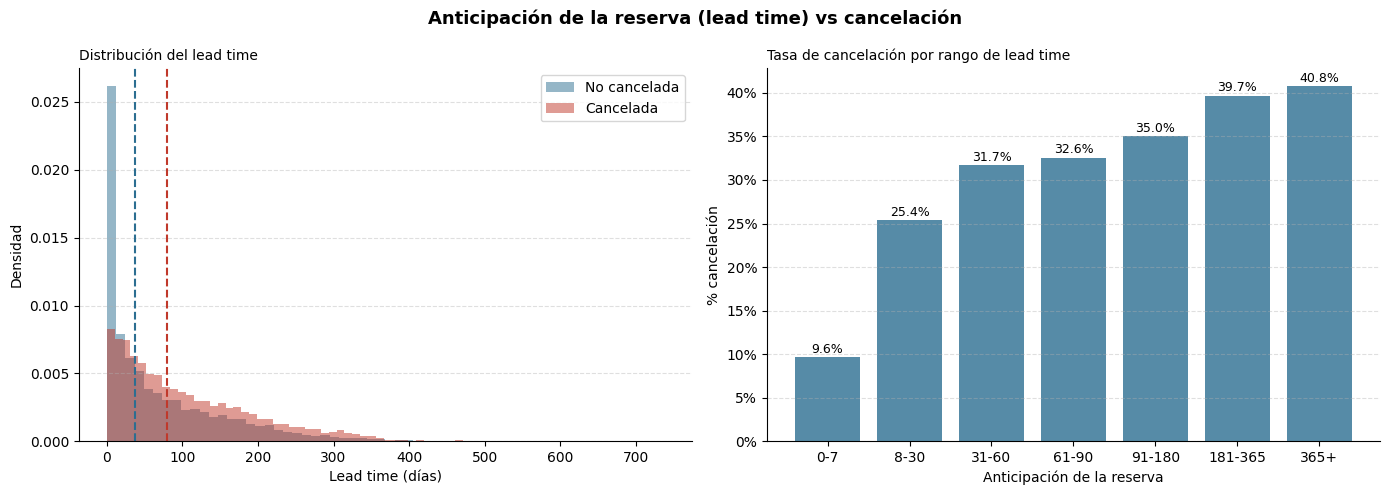

In [50]:
# ── 4.2 Lead time vs cancelación ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Anticipación de la reserva (lead time) vs cancelación",
             fontsize=13, fontweight="bold")

# ── Panel izquierdo: distribución por grupo ──
for cancelada, color, label in [(0, "#2C6E91", "No cancelada"), 
                                 (1, "#C0392B", "Cancelada")]:
    subset = df[df["is_canceled"] == cancelada]["lead_time"]
    axes[0].hist(subset, bins=60, alpha=0.5, color=color, label=label, density=True)
    axes[0].axvline(subset.median(), color=color, linewidth=1.5, linestyle="--")

axes[0].set_xlabel("Lead time (días)", fontsize=10)
axes[0].set_ylabel("Densidad", fontsize=10)
axes[0].set_title("Distribución del lead time", fontsize=10, loc="left")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# ── Panel derecho: tasa de cancelación por rango de lead time ──
bins = [0, 7, 30, 60, 90, 180, 365, 740]
labels = ["0-7", "8-30", "31-60", "61-90", "91-180", "181-365", "365+"]

df["lead_time_rango"] = pd.cut(df["lead_time"], bins=bins, labels=labels)
tasa_por_rango = df.groupby("lead_time_rango", observed=True)["is_canceled"].mean() * 100

axes[1].bar(tasa_por_rango.index, tasa_por_rango.values, color="#2C6E91", alpha=0.8)
axes[1].set_xlabel("Anticipación de la reserva", fontsize=10)
axes[1].set_ylabel("% cancelación", fontsize=10)
axes[1].set_title("Tasa de cancelación por rango de lead time", fontsize=10, loc="left")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

for i, (idx, val) in enumerate(tasa_por_rango.items()):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


El gráfico de barras hace explícita la relación monotónica: a mayor anticipación,
mayor tasa de cancelación, sin excepción en ningún rango. Esto pordría explicarse como quien reserva con poca anticipación lo hace porque tiene planes concretos e inmediatos. Quien reserva con meses de antelación está especulando — asegura disponibilidad y tarifa, pero su situación personal, laboral o económica tiene mucho más tiempo para cambiar antes de la fecha de llegada. La reserva lejana es más un marcador de intención que un compromiso.

> **Implicación de negocio:** el lead time es uno de los predictores más accionables del riesgo de cancelación. La cadena podría implementar políticas de confirmación escalonadas (por ejemplo, solicitar depósito o reconfirmación a reservas con más de 90 días de anticipación) para convertir intención en compromiso.

## **Diferencias entre tipos de hotel**

Una primera comparación entre los dos tipos de hotel revela diferencias importantes en el comportamiento de las reservas. El City Hotel concentra la mayor cantidad de registros, con 53.274 reservas frente a 33.955 del Resort Hotel. Asimismo, presenta una tasa de cancelación significativamente más alta (30% frente a 23%), lo que indica una mayor volatilidad en las reservas realizadas en establecimientos urbanos.

Una posible explicación de esta diferencia se encuentra en el tiempo de anticipación con que se realizan las reservas. El City Hotel registra un lead time mediano de 51 días, ligeramente superior a los 47 días observados en el Resort Hotel. Aunque la diferencia parece modesta, el análisis previo mostró una relación clara y monotónica entre el lead time y la probabilidad de cancelación: a medida que aumenta la anticipación de la reserva, aumenta también la tasa de cancelación.

También se observan diferencias en el perfil de consumo. El City Hotel presenta una tarifa diaria (ADR) mediana de €105,30, considerablemente superior a los €79,50 registrados en el Resort Hotel. Por su parte, las estancias en el Resort Hotel son más prolongadas, con una duración mediana de cuatro noches frente a tres noches en el hotel urbano. Este patrón es consistente con la naturaleza vacacional de los resorts, donde los huéspedes suelen permanecer durante periodos más largos.

Finalmente, la evolución mensual de las tasas de cancelación muestra que ambos hoteles siguen tendencias similares a lo largo del tiempo, lo que sugiere la presencia de factores estacionales comunes. Sin embargo, el City Hotel mantiene niveles de cancelación superiores durante gran parte del período analizado, reforzando la idea de que las reservas urbanas están asociadas a una mayor incertidumbre y flexibilidad en la decisión final del huésped.

In [58]:
resumen_hotel = df.groupby("hotel").agg(
    n_reservas=("is_canceled","count"),
    pct_cancelacion=("is_canceled","mean"),
    lead_time_median=("lead_time","median"),
    adr_median=("adr","median"),
    noches_median=("total_nights","median")
).round(2).reset_index()

# Formato legible
resumen_hotel["pct_cancelacion"] = (resumen_hotel["pct_cancelacion"] * 100).round(1).astype(str) + "%"
resumen_hotel["n_reservas"] = resumen_hotel["n_reservas"].apply(lambda x: f"{x:,}")
resumen_hotel["adr_median"] = resumen_hotel["adr_median"].apply(lambda x: f"€{x:.2f}")
resumen_hotel["lead_time_median"] = resumen_hotel["lead_time_median"].apply(lambda x: f"{int(x)} días")
resumen_hotel["noches_median"] = resumen_hotel["noches_median"].apply(lambda x: f"{int(x)} noches")

resumen_hotel.columns = ["Hotel", "Reservas", "% Cancelación", 
                          "Lead Time (mediana)", "ADR (mediana)", "Estadía (mediana)"]

resumen_hotel.style\
    .set_properties(**{"text-align": "center"})\
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#2C6E91"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("padding", "8px 12px")
        ]},
        {"selector": "td", "props": [("padding", "7px 12px")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#f2f7fb")]},
    ])\
    .hide(axis="index")

Hotel,Reservas,% Cancelación,Lead Time (mediana),ADR (mediana),Estadía (mediana)
City Hotel,"53,274",30.0%,51 días,€105.30,3 noches
Resort Hotel,"33,955",23.0%,47 días,€79.50,4 noches


## **0.5 Análisis estadistico**

**Pregunta de investigación**: ¿Que factores se asocian con la cancelación de una reserva hotelera?

- **Lead time**: 
 **Hipótesis**
 
 Ho: El lead time tiene la misma distribución en reservas canceladas y no canceladas

 H1: El lead time difiere entre ambos grupos

 >Se rechaza la hipótesis nula. Existe evidencia estadística de que la distribución del tiempo de anticipación difiere entre reservas canceladas y no canceladas. En particular, las reservas canceladas presentan tiempos de anticipación mayores, lo que sugiere que una mayor anticipación incrementa la probabilidad de cancelación.

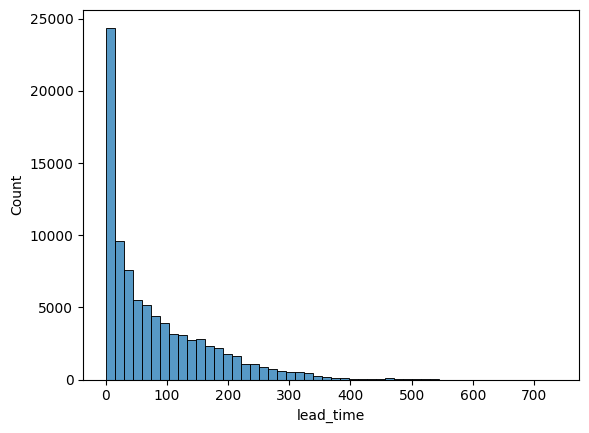

In [61]:
sns.histplot(df["lead_time"], bins=50)
plt.show()

In [62]:
df["lead_time"].skew()

np.float64(1.430806487919176)

In [65]:
from scipy.stats import mannwhitneyu

canceladas = df.loc[df["is_canceled"] == 1, "lead_time"]
no_canceladas = df.loc[df["is_canceled"] == 0, "lead_time"]

stat, p = mannwhitneyu(canceladas, no_canceladas)

print("Estadístico U:", stat)
print("Valor p:", p)

Estadístico U: 980731857.5
Valor p: 0.0


**Tipo de déposito y cancelación** 
**Hipótesis**

Para evaluar si el tipo de depósito está asociado con la cancelación de una reserva se realizó una prueba de independencia Chi-cuadrado.

H0: La cancelación es independiente del tipo de depósito.

H1: Existe asociación entre ambas variables.


In [71]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df["deposit_type"], df["is_canceled"])

chi2, p, dof, expected = chi2_contingency(tabla)

print("Frecuencias observadas")
print(tabla)

print("\nFrecuencias esperadas")
print(
    pd.DataFrame(
        expected,
        index=tabla.index,
        columns=tabla.columns
    )
)

print(f"Chi² = {chi2:.2f}")
print(f"p = {p:.20f}")
print(f"gl = {dof}")

Frecuencias observadas
is_canceled       0      1
deposit_type              
No Deposit    63084  23000
Non Refund       55    983
Refundable       81     26

Frecuencias esperadas
is_canceled         0        1
deposit_type                  
No Deposit   62390.15 23693.85
Non Refund     752.30   285.70
Refundable      77.55    29.45
Chi² = 2376.79
p = 0.00000000000000000000
gl = 2


>La prueba produjo un estadístico χ² = 2376.79 con 2 grados de libertad y un p-valor inferior a 0.001. Por lo tanto, se rechaza la hipótesis nula y se concluye que existe una asociación estadísticamente significativa entre el tipo de depósito y la cancelación de las reservas.

El análisis de las proporciones revela diferencias importantes entre categorías. Las reservas sin depósito presentaron una tasa de cancelación del 26.7%, mientras que las reservas con depósito reembolsable registraron una tasa similar (24.3%). En contraste, las reservas clasificadas como Non Refund alcanzaron una tasa de cancelación del 94.7%, muy superior a la observada en las demás categorías.

Estos resultados sugieren que el tipo de depósito contiene información relevante para explicar el comportamiento de cancelación. En particular, la categoría Non Refund muestra un patrón marcadamente diferente al resto de las reservas, por lo que constituye uno de los factores más fuertemente asociados con la cancelación dentro del conjunto de datos.

**Canal de distribución**

H0: el canal de distribución y la cancelación son variables independientes.

H1: existe una asociación entre el canal de distribución y la cancelación.

Debido a que ambas variables son categóricas, se aplicó una prueba Chi-cuadrado de independencia.

In [76]:
cancelacion_canal = pd.crosstab(
    df["distribution_channel"],
    df["is_canceled"],
    normalize="index"
) * 100

cancelacion_canal.round(2)


is_canceled,0,1
distribution_channel,,
Corporate,87.24,12.76
Direct,85.15,14.85
GDS,80.11,19.89
TA/TO,69.00,31.00
Undefined,20.00,80.00


In [ ]:
chi2, p, dof, expected = chi2_contingency(tabla)

print(f"Chi² = {chi2:.2f}")
print(f"p = {p:.20f}")
print(f"gl = {dof}")

Chi² = 2027.42
p = 0.00000000000000000000
gl = 4


>La prueba arrojó un estadístico χ² = 2027.42 con 4 grados de libertad y un p-valor inferior a 0.001. Por lo tanto, se rechaza la hipótesis nula y se concluye que existe una asociación estadísticamente significativa entre el canal de distribución y la cancelación de las reservas.

El análisis de las tasas de cancelación muestra diferencias importantes entre canales. Las reservas gestionadas a través de agencias de viaje y tour operadores (TA/TO) registran una tasa de cancelación del 31%, superior a la observada en los canales directos (14.9%) y corporativos (12.8%). Por su parte, el canal GDS presenta una tasa intermedia cercana al 20%.

Estos resultados sugieren que la forma en que una reserva llega al hotel está relacionada con su probabilidad de cancelación. En particular, las reservas intermediadas por agencias presentan una mayor incertidumbre, mientras que las reservas corporativas y directas tienden a materializarse con mayor frecuencia.


**Asociación entre tipo de hotel y cencelación**

Se evaluó si el tipo de hotel está relacionado con la probabilidad de cancelación de una reserva.

H0: El tipo de hotel y cancelación son idependientes.

H1: Existe asociación entre el tipo de hotel y la cancelación

Dado que ambas variables son categóricas, se aplicó una prueba Chi-cuadrado de independencia.

In [81]:


chi2, p, dof, expected = chi2_contingency(tabla)

print(f"Chi² = {chi2:.2f}")
print(f"p = {p:.20f}")
print(f"gl = {dof}")

Chi² = 454.58
p = 0.00000000000000000000
gl = 1


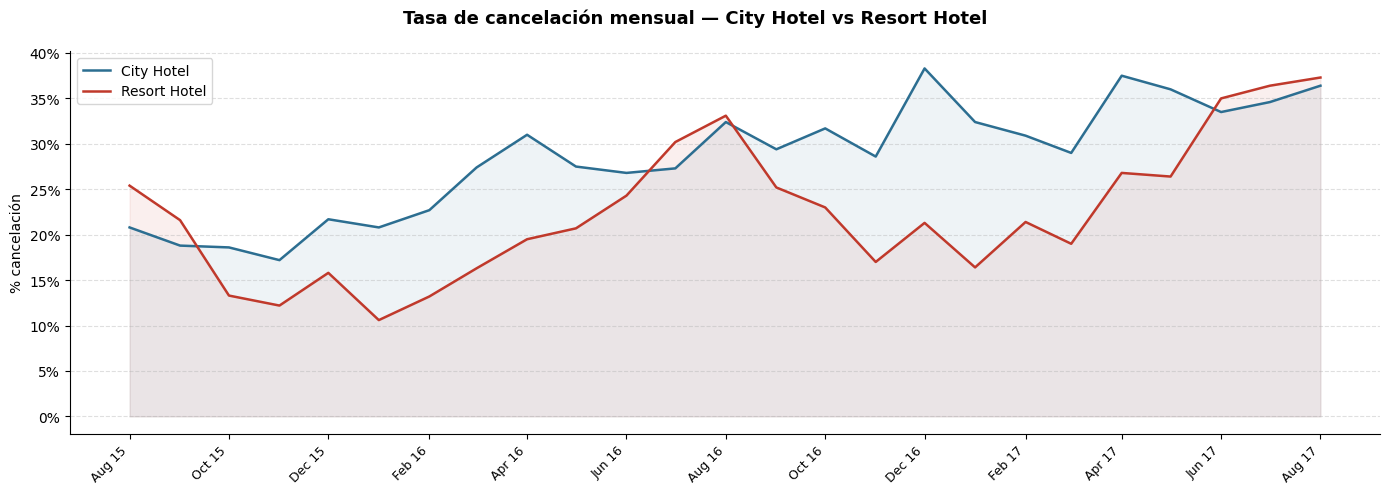

In [83]:
# ── 4.3 Diferencias entre tipos de hotel ─────────────────────────────────

hotel_ts = (
    df.groupby(["hotel", "periodo"])["is_canceled"]
    .mean()
    .reset_index()
)
hotel_ts["periodo_dt"] = hotel_ts["periodo"].dt.to_timestamp()
hotel_ts["pct_cancelacion"] = (hotel_ts["is_canceled"] * 100).round(1)

# Excluimos julio 2015 — primer mes con datos incompletos
hotel_ts = hotel_ts[hotel_ts["periodo_dt"] >= "2015-08-01"]

city   = hotel_ts[hotel_ts["hotel"] == "City Hotel"]
resort = hotel_ts[hotel_ts["hotel"] == "Resort Hotel"]

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Tasa de cancelación mensual — City Hotel vs Resort Hotel",
             fontsize=13, fontweight="bold")

ax.plot(city["periodo_dt"], city["pct_cancelacion"],
        color="#2C6E91", linewidth=1.8, label="City Hotel")
ax.fill_between(city["periodo_dt"], city["pct_cancelacion"],
                alpha=0.08, color="#2C6E91")

ax.plot(resort["periodo_dt"], resort["pct_cancelacion"],
        color="#C0392B", linewidth=1.8, label="Resort Hotel")
ax.fill_between(resort["periodo_dt"], resort["pct_cancelacion"],
                alpha=0.08, color="#C0392B")

ax.set_ylabel("% cancelación", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %y"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

>La prueba produjo un estadístico χ² = 454.58 con 1 grado de libertad y un p-valor inferior a 0.001. Por lo tanto, se rechaza la hipótesis nula y se concluye que existe una asociación estadísticamente significativa entre el tipo de hotel y la cancelación de las reservas.

Este resultado es consistente con otros hallazgos del análisis. El City Hotel registra mayores tiempos de anticipación en las reservas (lead time) y estancias más cortas, características que suelen estar asociadas con una mayor flexibilidad en los planes de viaje y, en consecuencia, con una mayor probabilidad de cancelación.

 **Asociación entre ADR y cancelación**

Se evaluó si la tarifa diaria promedio de la reserva (Average Daily Rate, ADR) difiere entre las reservas canceladas y las no canceladas.

H0: la distribución de ADR es la misma para ambos grupos.

H1: la distribución de ADR difiere entre reservas canceladas y no canceladas.

Debido a la naturaleza asimétrica de la variable y al tamaño de la muestra, se utilizó la prueba no paramétrica de Mann-Whitney.


In [84]:
df.groupby("is_canceled")["adr"].median()

is_canceled
0    94.89
1   109.80
Name: adr, dtype: float64

In [85]:
from scipy.stats import mannwhitneyu

canceladas = df.loc[df["is_canceled"] == 1, "adr"]
no_canceladas = df.loc[df["is_canceled"] == 0, "adr"]

stat, p = mannwhitneyu(canceladas, no_canceladas)

print(f"U = {stat}")
print(f"p = {p}")

U = 898346128.5
p = 0.0


>La prueba produjo un estadístico U = 898,346,128.5 y un p-valor inferior a 0.001, por lo que se rechaza la hipótesis nula. Existe evidencia estadísticamente significativa de diferencias en la tarifa diaria promedio entre reservas canceladas y no canceladas.

En particular, las reservas canceladas presentan una mediana de ADR de €109.80, mientras que las reservas no canceladas registran una mediana de €94.89. Este resultado sugiere que las reservas de mayor valor económico tienen una mayor probabilidad de ser canceladas.

**Asociación entre el segmento de mercado y la cancelación**

Se evaluó si el segmento de mercado al que pertenece una reserva está asociado con la probabilidad de cancelación.

H0: el segmento de mercado y la cancelación son variables independientes.

H1: existe una asociación entre ambas variables.

Debido a que ambas variables son categóricas, se aplicó una prueba Chi-cuadrado de independencia.


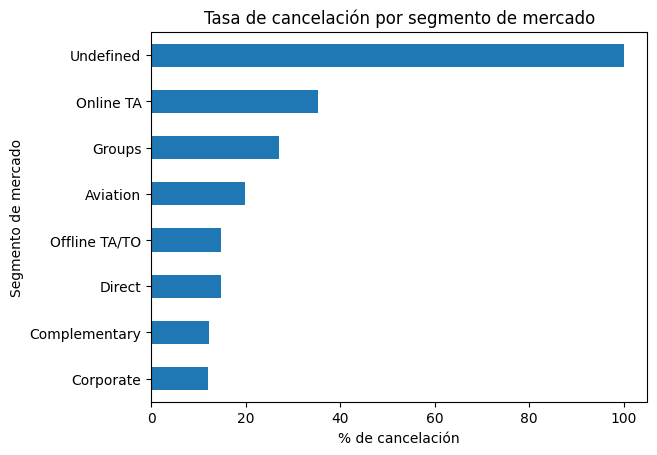

In [86]:
(
    df.groupby("market_segment")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values()
      .plot(kind="barh")
)

plt.xlabel("% de cancelación")
plt.ylabel("Segmento de mercado")
plt.title("Tasa de cancelación por segmento de mercado")
plt.show()

In [87]:

tabla = pd.crosstab(
    df["market_segment"],
    df["is_canceled"]
)

chi2, p, dof, expected = chi2_contingency(tabla)

print(f"Chi² = {chi2:.2f}")
print(f"p = {p:.20f}")
print(f"gl = {dof}")

Chi² = 4270.08
p = 0.00000000000000000000
gl = 7


>El análisis de las tasas de cancelación muestra diferencias importantes entre segmentos. Las reservas provenientes de agencias de viaje en línea (Online TA) presentan una tasa de cancelación del 35.4%, la más alta entre los segmentos con un volumen relevante de observaciones. Las reservas de grupos también muestran una elevada propensión a cancelar (27.1%). En contraste, los segmentos corporativo (12.1%), complementario (12.3%) y directo (14.8%) exhiben tasas considerablemente menores.

Estos resultados sugieren que el propósito y el canal comercial de la reserva influyen en la probabilidad de cancelación. Las reservas asociadas a intermediarios digitales y grupos presentan una mayor incertidumbre, mientras que las reservas corporativas y directas reflejan compromisos más estables y una menor propensión a ser canceladas.

**Análisis multivariado mediante regresión logística**

Las pruebas estadísticas realizadas previamente permitieron identificar múltiples factores asociados con la cancelación de reservas. Sin embargo, estos análisis fueron de naturaleza bivariada, es decir, evaluaron cada variable de manera independiente. Aunque este enfoque permite detectar asociaciones, no permite determinar si dichas relaciones se mantienen una vez que se controlan simultáneamente otros factores que también podrían influir en la cancelación.

Con el fin de evaluar el efecto conjunto de las variables analizadas, se estimó un modelo de regresión logística. Esta técnica es apropiada cuando la variable dependiente es dicotómica, como ocurre en este caso, donde una reserva puede encontrarse en uno de dos estados: cancelada (1) o no cancelada (0). La regresión logística permite estimar cómo cambia la probabilidad de cancelación en función de diversas características de la reserva, manteniendo constantes las demás variables incluidas en el modelo.

El modelo incorporó las variables lead_time, adr, hotel, distribution_channel, market_segment y has_company. Inicialmente también se intentó incluir la variable deposit_type, dado que en el análisis bivariado mostró una de las asociaciones más fuertes con la cancelación. Sin embargo, durante la estimación surgieron problemas de convergencia. Al examinar la distribución de los datos se observó que las reservas clasificadas como Non Refund presentaban una tasa de cancelación cercana al 95%, generando una situación cercana a la separación perfecta. En estas circunstancias, la variable predice el resultado con demasiada precisión, dificultando la estimación estable de los coeficientes mediante máxima verosimilitud. Por esta razón, la variable fue excluida del modelo multivariado y su efecto se interpretó a partir de los resultados obtenidos en el análisis de asociación mediante Chi-cuadrado. 

Asimismo, se excluyeron las categorías Undefined presentes en las variables market_segment y distribution_channel, debido a que representaban un número muy reducido de observaciones y generaban problemas de estabilidad en la estimación.

In [95]:
import statsmodels.formula.api as smf

In [108]:
vars_modelo = [
    "lead_time",
    "adr",
    "hotel",
    "distribution_channel",
    "market_segment",
    "has_company"
]

df_model = df[
    (df["market_segment"] != "Undefined") &
    (df["distribution_channel"] != "Undefined")
].copy()

modelo = smf.logit(
    """
    is_canceled ~ lead_time
                + adr
                + C(hotel)
                + C(distribution_channel)
                + C(market_segment)
                + has_company
    """,
    data=df_model
).fit(maxiter=100)

modelo.summary()

Optimization terminated successfully.
         Current function value: 0.540772
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:                87224
Model:                          Logit   Df Residuals:                    87210
Method:                           MLE   Df Model:                           13
Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                 0.08090
Time:                        11:57:23   Log-Likelihood:                -47168.
converged:                       True   LL-Null:                       -51320.
Covariance Type:            nonrobust   LLR p-value:                     0.000
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.0636      0.181     -5.889      0.000      -1.418      -0.710
C(hotel)[T.Resort Hotel]              -0.1938      0.017    -11.408      0.000      -0.227      -0.161
C(distribution_channel)[T.Direct]     -0.0712      0.105     -0.681      0.496      -0.276       0.134
C(distribution_channel)[T.GDS]        -0.0761      0.211     -0.361      0.718      -0.489       0.337
C(distribution_channel)[T.TA/TO]       0.2689      0.091      2.963      0.003       0.091       0.447
C(market_segment)[T.Complementary]    -0.6388      0.224     -2.849      0.004      -1.078      -0.199
C(market_segment)[T.Corporate]        -0.5106      0.175     -2.917      0.004      -0.854      -0.167
C(market_segment)[T.Direct]           -1.2648      0.202     -6.254      0.000      -1.661      -0.868
C(market_segment)[T.Groups]           -1.0030      0.190     -5.281      0.000      -1.375      -0.631
C(market_segment)[T.Offline TA/TO]    -1.7719      0.193     -9.186      0.000      -2.150      -1.394
C(market_segment)[T.Online TA]        -0.6005      0.191     -3.139      0.002      -0.976      -0.226
lead_time                              0.0049   9.38e-05     52.419      0.000       0.005       0.005
adr                                    0.0037      0.000     22.782      0.000       0.003       0.004
has_company                           -0.8501      0.074    -11.548      0.000      -0.994      -0.706
======================================================================================================
"""

In [111]:
np.exp(modelo.params).round(3)

Intercept                            0.34
C(hotel)[T.Resort Hotel]             0.82
C(distribution_channel)[T.Direct]    0.93
C(distribution_channel)[T.GDS]       0.93
C(distribution_channel)[T.TA/TO]     1.31
C(market_segment)[T.Complementary]   0.53
C(market_segment)[T.Corporate]       0.60
C(market_segment)[T.Direct]          0.28
C(market_segment)[T.Groups]          0.37
C(market_segment)[T.Offline TA/TO]   0.17
C(market_segment)[T.Online TA]       0.55
lead_time                            1.00
adr                                  1.00
has_company                          0.43
dtype: float64

El modelo final convergió satisfactoriamente y resultó globalmente significativo (p < 0.001), indicando que las variables incluidas aportan información relevante para explicar la probabilidad de cancelación de una reserva.

Los resultados muestran que el lead time constituye uno de los factores más importantes asociados con la cancelación. Manteniendo constantes las demás variables, cada día adicional de anticipación incrementa ligeramente las probabilidades de cancelación. Aunque el efecto diario es pequeño, su acumulación a lo largo de varias semanas o meses resulta considerable, reforzando la evidencia observada en los análisis descriptivos y en la prueba de Mann-Whitney.

La variable ADR también presentó una asociación positiva y estadísticamente significativa. Las reservas con tarifas más elevadas mostraron una mayor propensión a ser canceladas, lo que sugiere que el valor económico de la reserva influye en la decisión final del huésped.

Respecto al tipo de establecimiento, las reservas realizadas en Resort Hotel presentaron aproximadamente un 18% menos probabilidades de cancelarse que aquellas efectuadas en City Hotel, manteniendo constantes las demás variables. Este resultado es consistente con los análisis previos, donde los hoteles urbanos exhibieron tasas de cancelación superiores.

En cuanto a las características comerciales de la reserva, se observó que las reservas asociadas a una empresa (has_company) presentan aproximadamente un 57% menos probabilidades de cancelación que las reservas sin vínculo corporativo. Este hallazgo refuerza la idea de que las reservas empresariales suelen responder a necesidades más definidas y, por tanto, son menos susceptibles a modificaciones o cancelaciones.

Finalmente, tanto el segmento de mercado como algunos canales de distribución mantuvieron efectos significativos una vez controladas las demás variables. En particular, las reservas gestionadas mediante intermediarios turísticos mostraron una mayor propensión a la cancelación, mientras que los segmentos corporativos y directos exhibieron una mayor estabilidad.

En conjunto, los resultados del modelo logístico confirman que la cancelación de una reserva es un fenómeno multifactorial. Variables relacionadas con la planificación del viaje, el valor económico de la reserva, el tipo de establecimiento y las características comerciales del cliente contribuyen de manera significativa a explicar la probabilidad de cancelación.

## **05. Tabla resumen de métricas**

Con el fin de sintetizar la información operativa y comercial del conjunto de datos, se construyó una tabla resumen agregada por hotel y período mensual. Esta estructura permite analizar simultáneamente el volumen de reservas, el comportamiento de las cancelaciones y los principales indicadores de desempeño económico a lo largo del tiempo.

La agregación se realizó utilizando como unidad de análisis la combinación entre el tipo de hotel y el período de llegada de los huéspedes. Para cada grupo se calcularon las siguientes métricas:

- Número total de reservas registradas.
- Porcentaje de cancelación.
- Tiempo promedio de anticipación de la reserva (lead time).
- Número promedio de noches por estancia.
- Tarifa diaria promedio (Average Daily Rate, ADR).
- Ingreso estimado total.

El ingreso estimado se calculó a nivel de reserva como el producto entre la tarifa diaria promedio y el número total de noches reservadas. Posteriormente, los ingresos fueron agregados por período considerando únicamente las reservas efectivamente realizadas, asignando valor cero a las reservas canceladas.

La tabla resultante proporciona una visión integrada del desempeño de los hoteles a lo largo del tiempo y constituye una herramienta útil para identificar patrones estacionales, cambios en la demanda, variaciones en los ingresos y diferencias en el comportamiento de cancelación entre establecimientos.



In [113]:
tabla_resumen = (
    df.groupby(["hotel", "periodo"])
      .agg(
          reservas=("is_canceled", "size"),
          pct_cancelacion=("is_canceled", lambda x: x.mean() * 100),
          lead_time_promedio=("lead_time", "mean"),
          noches_promedio=("total_nights", "mean"),
          adr_promedio=("adr", "mean"),
          ingreso_estimado=("ingreso_estimado", "sum")
      )
      .reset_index()
)

tabla_resumen = tabla_resumen.round({
    "pct_cancelacion": 2,
    "lead_time_promedio": 1,
    "noches_promedio": 2,
    "adr_promedio": 2,
    "ingreso_estimado": 2
})

tabla_resumen = tabla_resumen.sort_values(
    ["hotel", "periodo"]
)

tabla_resumen.head(10)

,hotel,periodo,reservas,pct_cancelacion,lead_time_promedio,noches_promedio,adr_promedio,ingreso_estimado
0,City Hotel,2015-07,393,59.03,114.10,3.47,67.15,29450.71
1,City Hotel,2015-08,1101,20.80,40.90,2.98,83.43,214566.27
2,City Hotel,2015-09,1667,18.78,47.80,2.85,107.12,430529.36
3,City Hotel,2015-10,1555,18.59,46.60,2.83,95.33,349082.95
4,City Hotel,2015-11,795,17.23,42.00,3.02,74.08,141456.88
5,City Hotel,2015-12,1015,21.67,38.10,3.05,83.08,187436.54
6,City Hotel,2016-01,1030,20.78,25.90,2.95,75.77,156350.48
7,City Hotel,2016-02,1655,22.66,27.70,3.01,82.80,291239.96
8,City Hotel,2016-03,2363,27.38,43.70,3.14,94.15,460493.48
9,City Hotel,2016-04,2410,31.04,61.80,3.05,103.94,500519.77


## **07. Riesgos para un futuro modelo**

Si este conjunto de datos se utilizara para entrenar un modelo predictivo de cancelaciones, sería necesario evaluar cuidadosamente qué variables estarían realmente disponibles en el momento en que se desea realizar la predicción. Utilizar información que solo se conoce después de ocurrida la cancelación produciría un problema conocido como **fuga de información (data leakage)**, generando modelos aparentemente muy precisos pero imposibles de utilizar en escenarios reales.

Una de las variables que claramente no debería utilizarse es **reservation_status**. Esta variable indica el estado final de la reserva (*Check-Out*, *Canceled* o *No-Show*), información que solo se conoce después de que el proceso de reserva ha concluido. Incluirla implicaría entregar al modelo una versión casi directa de la variable objetivo.

Por la misma razón, tampoco debería utilizarse **reservation_status_date**, ya que corresponde a la fecha en la que se registró el estado final de la reserva. Esta información incorpora conocimiento posterior a la decisión de cancelar y, por tanto, constituye una fuente directa de fuga de información.

También debe prestarse especial atención a variables derivadas construidas durante el análisis. Por ejemplo, **ingreso_estimado** no sería una variable válida para predecir cancelaciones porque fue calculada utilizando la información de si la reserva finalmente se concretó o no. En su construcción se asignó ingreso cero a las reservas canceladas, incorporando explícitamente la variable objetivo dentro del predictor.

Otra variable potencialmente problemática es **company** en su forma original. Los identificadores numéricos de empresas no representan magnitudes ni categorías ordenadas y podrían inducir patrones artificiales difíciles de generalizar. Por esta razón, resulta más apropiado utilizar variables derivadas como la presencia o ausencia de una empresa asociada a la reserva.


Finalmente, para evaluar adecuadamente el desempeño de un modelo predictivo sería recomendable utilizar una partición temporal de los datos, entrenando con observaciones más antiguas y validando con observaciones más recientes. De esta manera se simula de forma más realista el escenario en el que el modelo deberá realizar predicciones sobre reservas futuras y se evita una sobreestimación artificial de su capacidad predictiva.


## **Conclusiones ejecutivas**

El análisis de las 87.229 reservas permitió identificar patrones claros asociados con la cancelación y caracterizar el comportamiento de los clientes en los dos tipos de hoteles incluidos en el estudio.

En primer lugar, se encontró que las cancelaciones no ocurren de manera aleatoria. Variables relacionadas con la anticipación de la reserva, el tipo de cliente, el canal de comercialización y las características económicas de la reserva presentan asociaciones estadísticamente significativas con la probabilidad de cancelación. Esto indica que la cancelación puede ser anticipada parcialmente a partir de la información disponible al momento de realizar la reserva.

Uno de los hallazgos más consistentes fue la relación entre el tiempo de anticipación (*lead time*) y la cancelación. Las reservas realizadas con varios meses de anticipación presentan una probabilidad significativamente mayor de ser canceladas que aquellas efectuadas cerca de la fecha de llegada. Este resultado sugiere que las reservas tempranas representan una intención de viaje más flexible, mientras que las reservas de última hora suelen corresponder a planes más definidos.

También se observaron diferencias relevantes entre tipos de hotel. El City Hotel registra una mayor tasa de cancelación que el Resort Hotel, mientras que este último presenta estancias más largas y una mayor estabilidad en las reservas. Esto evidencia que los hoteles urbanos y los vacacionales enfrentan dinámicas de demanda diferentes y, por tanto, requieren estrategias de gestión distintas.

Las características comerciales de la reserva también desempeñan un papel importante. Las reservas realizadas a través de agencias de viaje en línea y operadores turísticos presentan mayores tasas de cancelación, mientras que las reservas corporativas y las asociadas a empresas muestran un comportamiento considerablemente más estable. En particular, las reservas vinculadas a empresas presentan una probabilidad de cancelación sustancialmente menor que las reservas individuales.

Asimismo, las reservas con tarifas diarias más elevadas tienden a cancelarse con mayor frecuencia. Aunque el efecto individual es moderado, su persistencia en el análisis multivariado indica que el valor económico de la reserva constituye un factor relevante para comprender el comportamiento de los huéspedes.

La regresión logística confirmó que estos factores mantienen su influencia incluso cuando se analizan simultáneamente. Entre ellos destacan el tiempo de anticipación, el tipo de hotel, la tarifa diaria promedio y las características comerciales de la reserva, lo que sugiere que la cancelación es un fenómeno multifactorial que responde tanto a decisiones individuales de los clientes como a las condiciones bajo las cuales se realizó la reserva.

Finalmente, los resultados evidencian que este conjunto de datos contiene información suficiente para desarrollar modelos predictivos orientados a identificar reservas con alto riesgo de cancelación. No obstante, cualquier implementación futura deberá considerar cuidadosamente los riesgos de fuga de información y los posibles cambios en los patrones de comportamiento a lo largo del tiempo para garantizar que las predicciones sean válidas y útiles en contextos operativos reales.

